In [1]:
%load_ext autoreload
%autoreload 2
import os

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print(os.getcwd()) # should end in /medjudge-audit

/Users/berniceyan/medjudge-audit


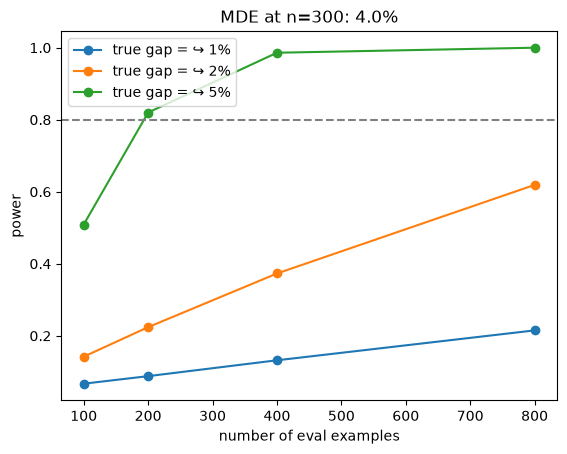

In [2]:
from judgeaudit.scoring import per_example_scores
from judgeaudit.power import power_curve, min_detectable_effect
import matplotlib.pyplot as plt
import pandas as pd

b1 = pd.read_json("results/grades_track_b1.jsonl", lines=True)
ex = per_example_scores(b1)
wide = ex.pivot_table(index="prompt_id", columns="response_model", values="score") 
diffs = (wide.iloc[:, 0] - wide.iloc[:, 1]).dropna().to_numpy()

res = power_curve(diffs)
for delta in (0.01, 0.02, 0.05):
    ns = sorted(n for (d, n) in res if d == delta)
    plt.plot(ns, [res[(delta, n)] for n in ns], marker="o", label=f"true gap = ↪ {delta:.0%}")

plt.axhline(0.8, ls="--", color="gray") # the conventional 80% power bar 
plt.xlabel("number of eval examples")
plt.ylabel("power")
plt.legend() 
plt.title(f"MDE at n=300: {min_detectable_effect(diffs, 300):.1%}") 
plt.savefig("results/fig_power.png", dpi=200, bbox_inches="tight")

In [3]:
import numpy as np

for n in (100, 200, 300, 400, 800):
    mde = min_detectable_effect(diffs, n)              # δ that formula says gives 80% power
    p = power_curve(diffs, deltas=(mde,), ns=(n,), n_sim=10000)[(mde, n)]
    print(f"n={n:4d}  MDE={mde:.4f}  simulated power at MDE = {p:.3f}")

n= 100  MDE=0.0697  simulated power at MDE = 0.810
n= 200  MDE=0.0493  simulated power at MDE = 0.804
n= 300  MDE=0.0403  simulated power at MDE = 0.807
n= 400  MDE=0.0349  simulated power at MDE = 0.801
n= 800  MDE=0.0247  simulated power at MDE = 0.802
